In [53]:
cd(joinpath(homedir(),"Dropbox/Online Coursework/Covid/ilm-src")); 

In [54]:
using Plots
pyplot()

Plots.PyPlotBackend()

In [55]:
using CovidSim_ilm

In [56]:
bismarck = (;fips=38015)
newyork = (;fips=36061)

(fips = 36061,)

In [72]:
seed_1_6 = seed_case_gen(1, [0,3,3,0,0], 1, nil, agegrps)

(::CovidSim_ilm.var"#scase#59"{Int64, Vector{Int64}, Int64, Int64, Vector{Int64}}) (generic function with 1 method)

In [73]:
alldat, env, series = run_a_sim(180, bismarck.fips, showr0=false, silent=true,
        spreadcases=[],
        runcases=[seed_1_6]);
geo = alldat.geo;

*** seed day 1 locale 38015....
(sprtime, trtime, histtime) = (0.5512516940000001, 0.37098310599999995, 0.11940053899999999)


# Smaller City: No social distancing

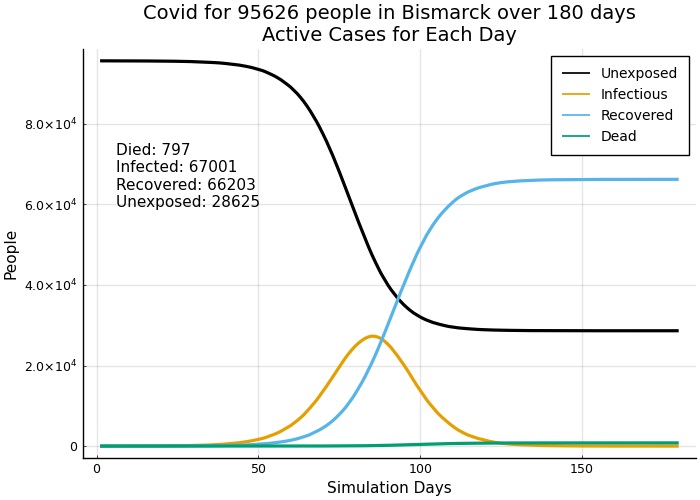

In [58]:
bisfull=cumplot(series,bismarck.fips,geo=geo)

In [59]:
virus_outcome(series, bismarck.fips)

Dict{String, Float64} with 4 entries:
  "unexposed"  => 0.427271
  "infectious" => 1.49265e-5
  "dead"       => 0.0118964
  "recovered"  => 0.988178

In [60]:
str_50 = sd_gen(start=50, comply=.9, cf=(.5,1.2), tf=(.18,.42))
alldat, env, series = run_a_sim(180, bismarck.fips, showr0=false, silent=true,
    spreadcases=[str_50],
    runcases=[seed_1_6]);

*** seed day 1 locale 38015....
(sprtime, trtime, histtime) = (0.4285938489999997, 0.08089535100000002, 0.116219834)


# Moderately Strong Social Distancing starts on Day 50

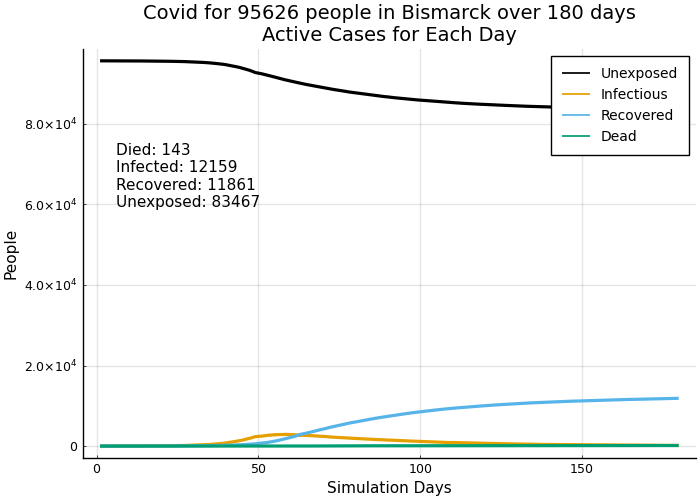

In [61]:
bissd50=cumplot(series,bismarck.fips,geo=geo)

In [62]:
virus_outcome(series, bismarck.fips)

Dict{String, Float64} with 4 entries:
  "unexposed"  => 6.86802
  "infectious" => 0.0127541
  "dead"       => 0.0117666
  "recovered"  => 0.975973

In [63]:
open = sd_gen(start=80, comply=0.7, cf=(.5,1.5), tf=(.25,.50))

Spreadcase(80, (0.5, 1.5), (0.25, 0.5), 0.7)

In [64]:
alldat, env, series = run_a_sim(180,bismarck.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6]);

*** seed day 1 locale 38015....
(sprtime, trtime, histtime) = (0.5629661560000001, 0.24314258800000002, 0.12459774299999993)


# With low cases and deaths very low-->open up significantly, but not completely

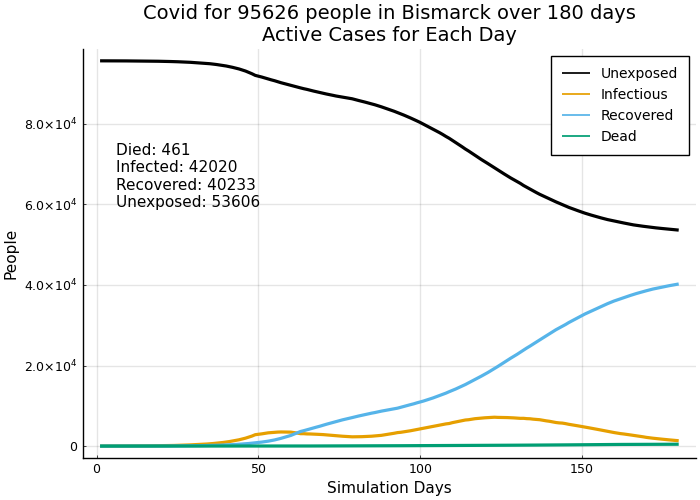

In [65]:
bisopen=cumplot(series,bismarck.fips,geo=geo)

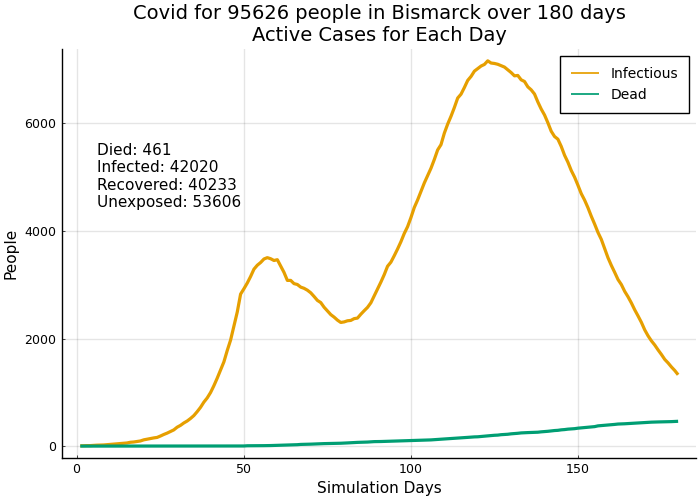

In [66]:
bisbump=cumplot(series,bismarck.fips,[infectious, dead],geo=geo)

In [67]:
virus_outcome(series, bismarck.fips)

Dict{String, Float64} with 4 entries:
  "unexposed"  => 1.27591
  "infectious" => 0.0315609
  "dead"       => 0.0109725
  "recovered"  => 0.957609

# Adopt Test, Trace and Isolate

In [70]:
t_n_t100_160=CovidSim_ilm.t_n_t_case_gen(100,160,tc_perday=1000, test_delay=3,
    breakout_pct=0.2, q_comply=0.75,past_contacts=false)

(::CovidSim_ilm.var"#scase#69"{CovidSim_ilm.var"#scase#68#70"{Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Int64, Int64, Int64, Bool, Bool, Int64, Int64}}) (generic function with 1 method)

In [71]:
alldat, env, series = run_a_sim(180, bismarck.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6, t_n_t100_160]);

*** seed day 1 locale 38015....


LoadError: MethodError: no method matching (::CovidSim_ilm.var"#scase#69"{CovidSim_ilm.var"#scase#68#70"{Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Int64, Int64, Int64, Bool, Bool, Int64, Int64}})(::Int64, ::Dict{Int64, TypedTables.Table{NamedTuple{(:status, :agegrp, :cond, :lag, :recov_day, :dead_day, :cluster, :vax, :vax_day, :test, :test_day, :quar, :quar_day), Tuple{Int64, Int64, Int64, Int64, Int64, Int64, Int64, Bool, Int64, Bool, Int64, Bool, Int64}}, 1, NamedTuple{(:status, :agegrp, :cond, :lag, :recov_day, :dead_day, :cluster, :vax, :vax_day, :test, :test_day, :quar, :quar_day), Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Int64}, Vector{Int64}, BitVector, Vector{Int64}, BitVector, Vector{Int64}, BitVector, Vector{Int64}}}}}, ::Vector{Any}, ::Vector{Any}, ::SimEnv{Int64})
[0mClosest candidates are:
[0m  (::CovidSim_ilm.var"#scase#69")(::Any; opendat, isodat, testdat, env) at /Users/lewislevin/Dropbox/Onlin

# Apply Test, Trace and Isolate 
- test capacity of 1% of population per day
- quarantine compliance of 75%
- delay of 3 days returning test results

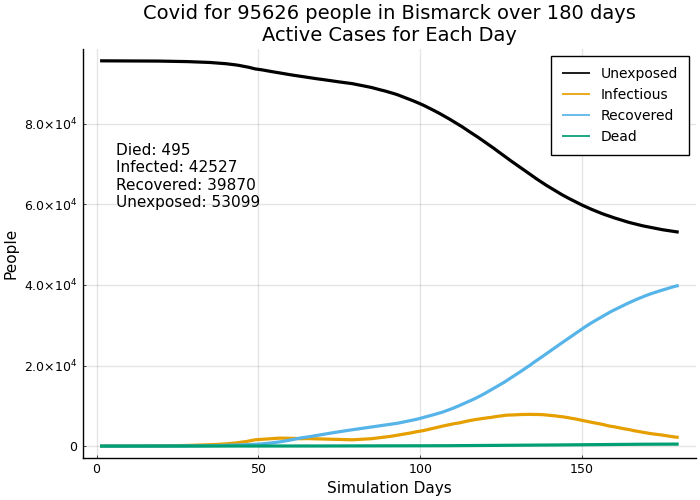

In [21]:
cumplot(series,38015,geo=geo)

# Apply Test, Trace and Isolate--raising test capacity to 5% of population

- 4800 tests per day (roughly 5% of population)
- quarantine compliance of 95%
- test results returned same day

In [22]:
t_n_t100_160=CovidSim_ilm.t_n_t_case_gen(100,160,tc_perday=4800, test_delay=0,
    breakout_pct=0.20, q_comply=0.95, past_contacts=false)

LoadError: UndefVarError: CovidSim not defined

In [23]:
alldat, env, series = run_a_sim(180,bismarck.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6, t_n_t100_160]);

LoadError: UndefVarError: t_n_t100_160 not defined

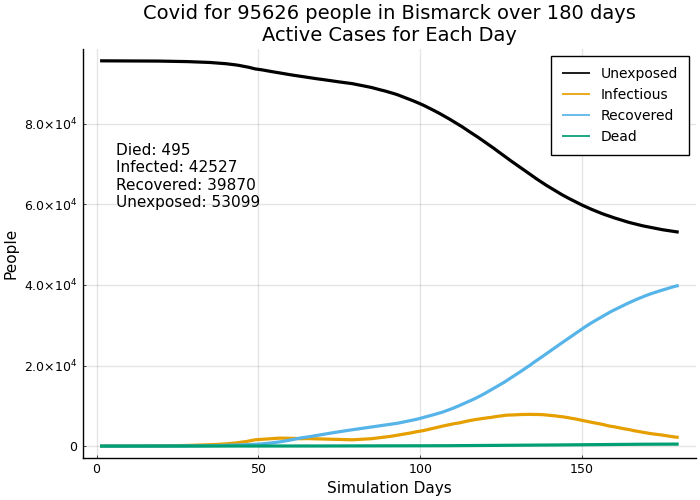

In [24]:
cumplot(series,bismarck.fips,geo=geo)

# Apply Test, Trace and Isolate
- testing capacity of 10% of the population
- quarantine compliance of 97%
- delay in obtaining test results of 0 days

In [25]:
t_n_t100_160=CovidSim_ilm.t_n_t_case_gen(100,160,tc_perday=10_000, test_delay=0,
    breakout_pct=0.20, q_comply=0.97,past_contacts=false)

LoadError: UndefVarError: CovidSim not defined

In [26]:
alldat, env, series = run_a_sim(180, bismarck.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6, t_n_t100_160]);

LoadError: UndefVarError: t_n_t100_160 not defined

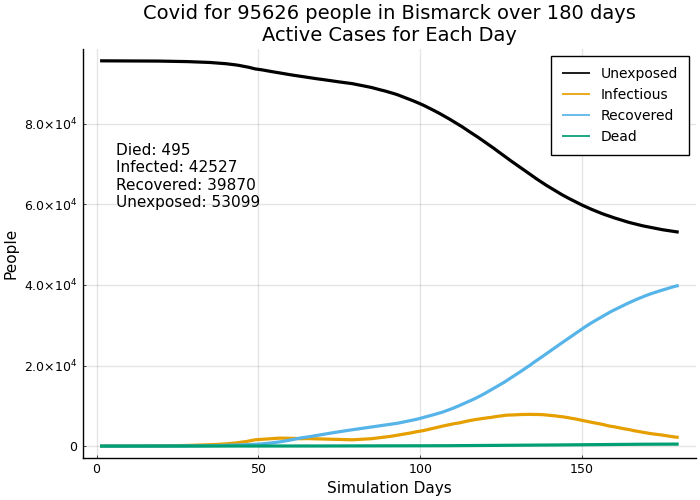

In [27]:
cumplot(series,bismarck.fips,geo=geo)

# Very large city: no social distancing

In [28]:
alldat, env, series = run_a_sim(180,newyork.fips, showr0=false, silent=true,
    spreadcases=[],
    runcases=[seed_1_6]);

*** seed day 1 locale 36061....
(sprtime, trtime, histtime) = (102.29083350800006, 40.09796598500003, 15.387967579)


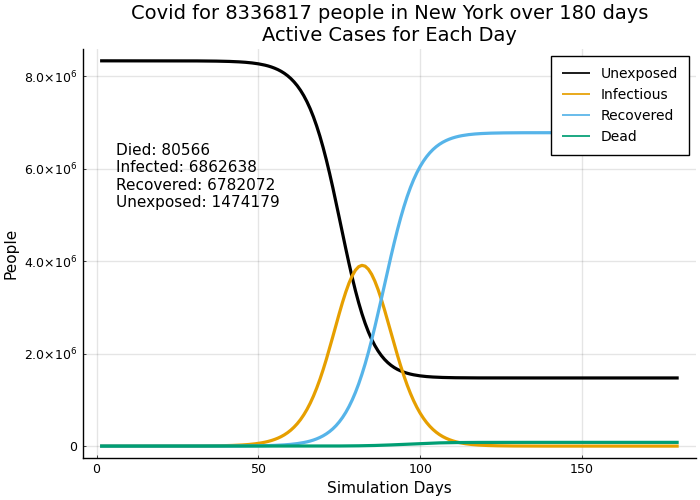

In [29]:
nycfull=cumplot(series, newyork.fips, geo=geo)

In [30]:
infection_outcome(series, newyork.fips)

LoadError: UndefVarError: infection_outcome not defined

In [31]:
str_50 = sd_gen(start=50, comply=.9, cf=(.5,1.2), tf=(.18,.42))
alldat, env, series = run_a_sim(180, newyork.fips, showr0=false, silent=true,
    spreadcases=[str_50],
    runcases=[seed_1_6]);

*** seed day 1 locale 36061....
(sprtime, trtime, histtime) = (80.62191744699999, 20.114629997999987, 15.460234352000002)


# Moderately Strong Social Distancing starts on Day 50

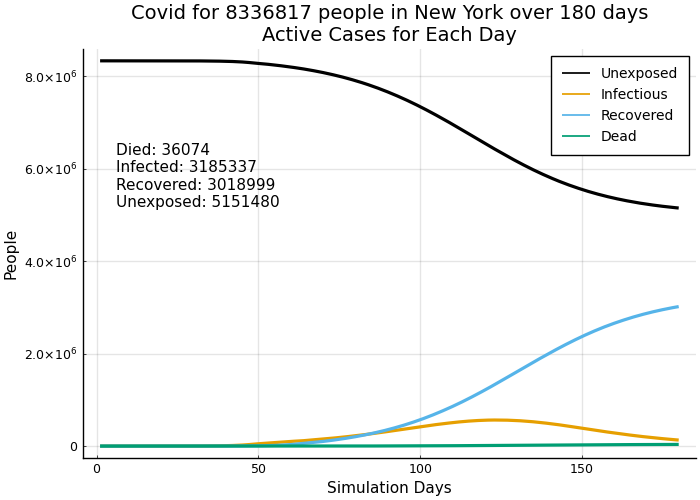

In [32]:
nycsd50=cumplot(series,newyork.fips,geo=geo)

Note: The total of deaths is a bit higher than NYC deaths as of May 23 at 21086, which is day 122, while the simulation is run for almost another 2 months.

In [33]:
virus_outcome(series, newyork.fips)

LoadError: UndefVarError: infection_outcome not defined

In [34]:
open = sd_gen(start=95, comply=0.7, cf=(.5,1.5), tf=(.25,.50))

Spreadcase(95, (0.5, 1.5), (0.25, 0.5), 0.7)

In [ ]:
alldat, env, series = run_a_sim(180, newyork.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6]);

# With declining cases and declining deaths-->open up later on day 95

In [ ]:
nycopen=cumplot(series,newyork.fips,geo=geo)

In [ ]:
nycbump=cumplot(series, newyork.fips, [infectious, dead],geo=geo)

Note: We don't see a "double-dip" pattern for New York City because the original curve of infection had not turned as sharply down, but had moderated considerably. When opening occurs, the infection rate looks like unrestrained virus transmission.

In [ ]:
t_n_t100_160=CovidSim_ilm.t_n_t_case_gen(100,160,tc_perday=80_000,breakout_pct=0.20, q_comply=0.75,past_contacts=false)

In [ ]:
alldat, env, series = run_a_sim(180,newyork.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6, t_n_t100_160]);

# Apply Test, Trace and Isolate: 
- 80,000 tests per day 
- quarantine compliance of 75%
- delay in returning test results of 3 days

In [ ]:
nyc_tnt_min = cumplot(series,newyork.fips,geo=geo)

# Apply Test, Trace and Isolate 

- 835,000 tests per day (roughly 10% of population)
- quarantine compliance of 95%
- test results returned same day

In [ ]:
t_n_t100_160=CovidSim_ilm.t_n_t_case_gen(100,160,tc_perday=835_000, test_delay=0,
    breakout_pct=0.20, q_comply=0.95, past_contacts=false)

In [ ]:
alldat, env, series = run_a_sim(180,newyork.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6, t_n_t100_160]);

In [ ]:
nyc_tnt_max = cumplot(series,newyork.fips,geo=geo)

Note: returning tests results same day results in 25% reduction in deaths compared to a delay of 3 days. 

# Apply Test, Trace and Isolate--raising test capacity to 5% of population

- 420,000 tests per day (roughly 5% of population)
- quarantine compliance of 95%
- test results returned same day

In [ ]:
t_n_t100_160=CovidSim_ilm.t_n_t_case_gen(100,160,tc_perday=420_000, test_delay=0,
    breakout_pct=0.20, q_comply=0.95, past_contacts=false)

In [ ]:
alldat, env, series = run_a_sim(180,newyork.fips, showr0=false, silent=true,
    spreadcases=[str_50, open],
    runcases=[seed_1_6, t_n_t100_160]);

In [ ]:
nyc_tnt_mid = cumplot(series,newyork.fips,geo=geo)